<a href="https://colab.research.google.com/github/JulTob/Data/blob/main/GaussianCalculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [366]:
class Gaussian():
    import random
    from math import sqrt, exp, pi, erf

    def seed(self, seed_value):
        self.rng.seed(seed_value)

    def __init__(self, mu=1, sigma = None):
        self.mu = mu
        self.sigma = sigma
        self.rng = self.random.Random()
        self.gen = self.rng.random

    def __str__(self):
        return f"Gaussian({self.mu}, {self.sigma})"

    def __add__(self, other):
        if isinstance(other, Gaussian):
            mu = self.mu + other.mu
            sigma = self.sigma + other.sigma
            return Gaussian(mu, sigma)
        else:
            mu = self.mu + other
            sigma = self.sigma
            return Gaussian(mu, sigma)

    def __neg__(self):
        mu = -self.mu
        sigma = self.sigma
        return Gaussian(mu, sigma)

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        if isinstance(other, Gaussian):
            mu = self.mu * other.mu
            sigma = self.sigma * other.sigma
            return Gaussian(mu, sigma)
        else:
            mu = self.mu + other
            sigma = self.sigma * (other ** 2)
            return Gaussian(mu, sigma)

    def __call__(self, N=None, seed=None):
        if seed is not None:
            self.seed(seed)
        if None == N:
            return self.rng.gauss(self.mu, self.sigma)
        if int==type(N):
            return ([self() for i in range(N)])

    def __iter__(self):
        while True:
            yield self()

    def deviation(self):
        return self.sigma

    def variance(self):
        return self.sigma ** 2

    def pdf(self, x):
        if self.sigma <= 0: return 0
        coefficient = 1 / (self.sigma * sqrt(2 * pi))
        exponent = -0.5 * ((x - self.mu) / self.sigma)**2
        return coefficient * exp(exponent)

    def cdf(self, x):
        if self.sigma <= 0: return 0
        z = (x - self.mu) / (self.sigma * sqrt(2))
        return 0.5 * (1 + erf(z))

    def area(self, start, end):
        if start >= end: raise ValueError("Start must be less than end.")
        return self.cdf(end) - self.cdf(start)

    def visualize(self, num_samples=100, seed=None):
        if num_samples <= 0: raise ValueError("Number of samples must be positive.")

        samples = self(num_samples, seed=seed)
        plt.figure(figsize=(12, 7))

        min_val = self.mu - 4 * self.sigma
        max_val = self.mu + 4 * self.sigma

        # Standard Deviation regions
        base_alpha = 0.10
        for i in range(1, 4):
            ds_alpha = base_alpha * (0.95 ** (i-1))
            lower = self.mu - i * self.sigma
            upper = self.mu + i * self.sigma
            plt.axvspan(lower, upper, color='gold',
                        alpha=ds_alpha)

        # Dot stacking logic with compensation for scale
        display_samples = sorted(samples)
        num_bins = 100
        bin_width = (max(samples) - min(samples)) / num_bins
        counts = {}
        x_coords = []
        y_coords = []

        # Calculate scale factor to match PDF height
        max_expected_count = 0
        temp_counts = {}
        for s in display_samples:
            b = round(s / bin_width)
            temp_counts[b] = temp_counts.get(b, 0) + 1
            if temp_counts[b] > max_expected_count: max_expected_count = temp_counts[b]

        max_pdf = self.pdf(self.mu)
        y_step = max_pdf / max_expected_count if max_expected_count > 0 else 0.01

        for s in display_samples:
            bin_idx = round(s / bin_width)
            slot = counts.get(bin_idx, 0)
            counts[bin_idx] = slot + 1
            x_coords.append(bin_idx * bin_width)
            y_coords.append(slot * y_step)

        plt.scatter(x_coords, y_coords, color='black',
                    alpha=0.6, s=15)

        # Theoretical PDF
        x_pdf = np.linspace(min_val, max_val, 500)
        y_pdf = [self.pdf(x) for x in x_pdf]
        plt.plot(x_pdf, y_pdf,
                 color='goldenrod',
                 linewidth=3,
                 linestyle=':',
                 label='Theoretical PDF')

        plt.axvline(self.mu, color='silver', linestyle='--', linewidth=4, alpha= 0.5, label=f'Mean (μ={self.mu})')

        plt.title(f'{self}')
        plt.xlabel('Value')
        plt.ylabel('Density Scale')
        plt.legend()
        plt.grid(True, alpha=0.1)
        plt.show()

Gaussian(3, 2)
-1.1738373459854283
-1.8362138903948608
0.0626456382559559
2.5143720932653446
1.3361004864680093
0.3142089109323289
0.8271083437545357


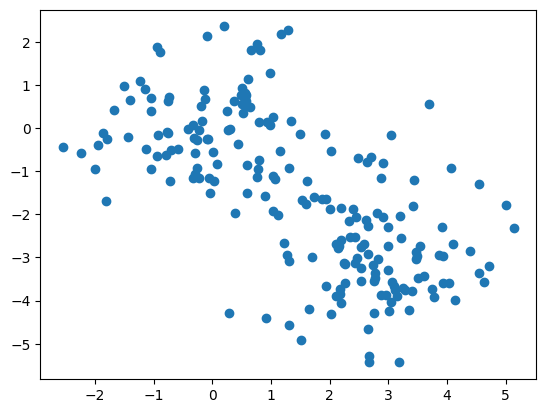

In [367]:
import matplotlib.pyplot as plt

g1 = Gaussian(0, 1)
g2 = Gaussian(3, 1)
g3 = g1 + g2
print(g3)

for i in g1(7):
    print(i)

plt.scatter(g1(100) + g2(100), g1(100)+ (-g2)(100))

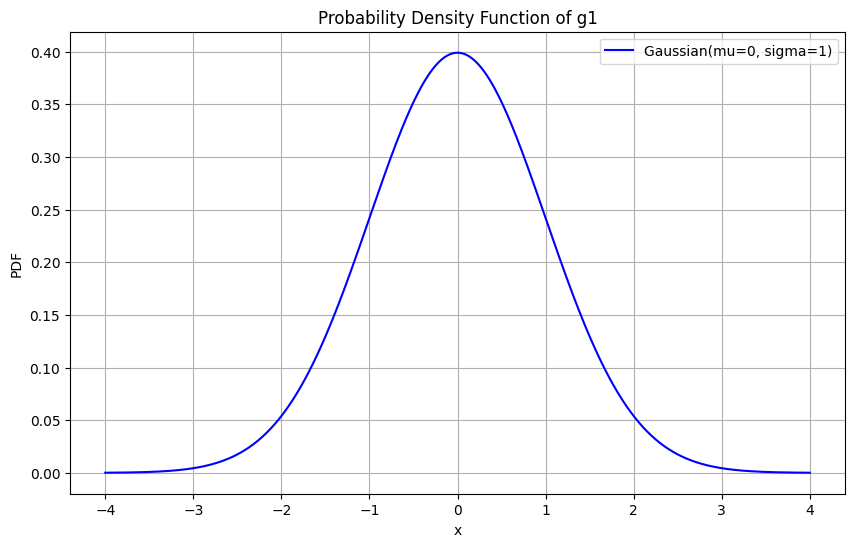

In [368]:
import numpy as np

# Define the range for x-values based on g1's mu and sigma
x_values = np.linspace(g1.mu - 4 * g1.sigma, g1.mu + 4 * g1.sigma, 500)

# Calculate PDF values for g1
pdf_values_g1 = [g1.pdf(x) for x in x_values]

# Plot the PDF
plt.figure(figsize=(10, 6))
plt.plot(x_values, pdf_values_g1, label=f'Gaussian(mu={g1.mu}, sigma={g1.sigma})', color='blue')
plt.title('Probability Density Function of g1')
plt.xlabel('x')
plt.ylabel('PDF')
plt.grid(True)
plt.legend()
plt.show()

In [369]:
g = Gaussian(0, 1) # Standard normal distribution
area_between_minus1_and_1 = g.area(-1, 1)
print(f"Area between -1 and 1 for standard normal: {area_between_minus1_and_1:.4f}")

g2 = Gaussian(5, 2)
area_for_g2 = g2.area(3, 7)
print(f"Area between 3 and 7 for Gaussian(5, 2): {area_for_g2:.4f}")

# Example of error handling for invalid sigma
try:
    g_invalid = Gaussian(0, 0)
    g_invalid.area(0, 1)
except ValueError as e:
    print(f"Error with invalid sigma: {e}")

# Example of error handling for invalid range
try:
    g.area(1, -1)
except ValueError as e:
    print(f"Error with invalid range: {e}")

Area between -1 and 1 for standard normal: 0.6827
Area between 3 and 7 for Gaussian(5, 2): 0.6827
Error with invalid range: Start must be less than end.


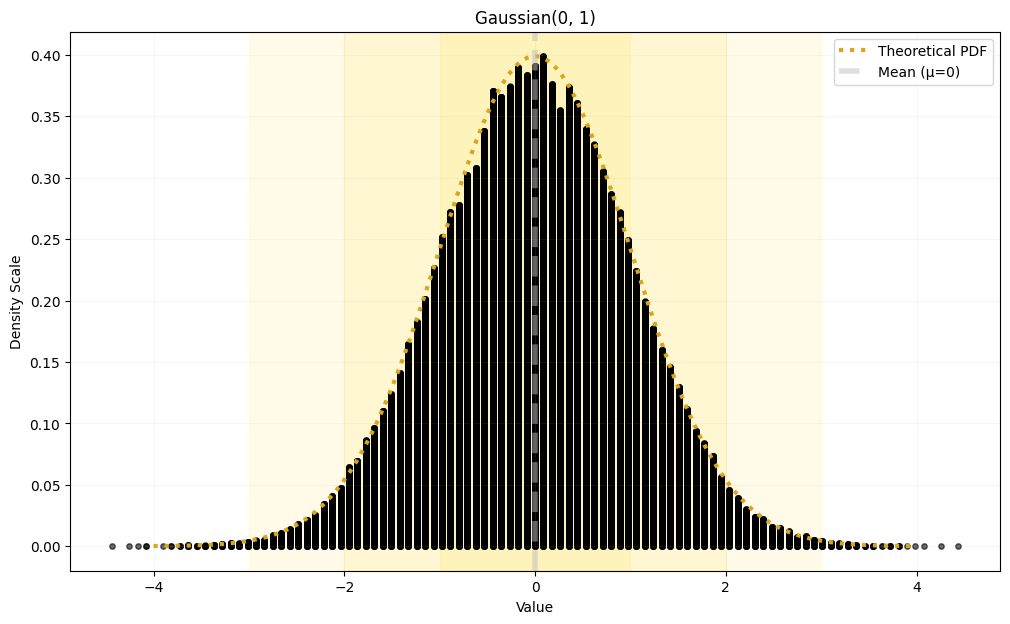

In [373]:
(g1).visualize(100000)